# 00. Filter and Subsample 2k videos from 20bn-jester-V1-videos Dataset 

This notebook loads and extracts a subset of 2,000 (4 classes, 500 videos per class) 20-bn-jester-v1 training videos for training a ResNet3D-18 model and Resnet50-LSTM hybrid model following the kaggle notebook linked [here](https://www.kaggle.com/code/peaceakhaze/notebook53b831d07d).
 

**Instructions for running notebook:**
1. Download the full dataset .zip from Kaggle link [here](https://www.kaggle.com/datasets/sanjanatg26/20bn-jester-v1-complete/data)
2. Extract the .tgz file from the .zip file 
3. Download the **20bn-jester-v1/annotations** folder from the [CVND---Gesture Recognition](https://github.com/udacity/CVND---Gesture-Recognition)repo from Udacity. This contains all the original full training, validation, test labels as .csv files.
4. Run the notebook cell-by-cell

**Outputs:** 

* **(1) Full 2,000 videos subsampled for project experiments**
    * 4 gesture classes: “Stop Sign”, “Swiping Left”, “Sliding Two Fingers Down”, “Thumbs Up”
    * 400 total videos per gesture class 
    * 400/50/50 train/val/test videos 
    * **/prod/raw_data/annotations**:
        * A folder containing .csv files for the train, val, and test video id and labels 
    * **/prod/raw_data/videos:**
        * A folder containing sub-folders train, val, test of the extracted videos for each set, respectively

* **(3) A small subsample from the 2k subsample for development testing**

    * **/dev/raw_data/annotations/train.csv:**
        * a .csv file containning 8 video id and labels (2 videos for each gesture class) randomly selected from the 2k subsample 
    * **/dev/raw_data/annotations/val.csv:**
        * a csv file containing 4 video id and labels (i.e., 1 video with its label from each of the 4 gesture classes) randomly sampled from the 2k subsample for validation 
    * **/dev/raw_data/annotations/test.csv:** 
        * .csv file containing 4 video id and labels (i.e., 1 video with its label from each of the 4 gesture classes) randomly sampled from the 2k subsample for testing 
    *  **/dev/raw_data/videos:**
        * folder containing the train, test, val videos for development testing

**Data source reference:**

 * Sanjana T G. (2025). 20bn-jester-v1-complete (Version 1) [Data set]. Kaggle. https://www.kaggle.com/datasets/sanjanatg26/20bn-jester-v1-complete/data

**Github links to jester labels**:

* [Link](https://raw.githubusercontent.com/udacity/CVND---Gesture-Recognition/master/20bn-jester-v1/annotations/jester-v1-train.csv) to train labels. 
* [Link](https://raw.githubusercontent.com/udacity/CVND---Gesture-Recognition/master/20bn-jester-v1/annotations/jester-v1-validation.csv) to validation labels.
* [Link](https://raw.githubusercontent.com/udacity/CVND---Gesture-Recognition/master/20bn-jester-v1/annotations/jester-v1-test.csv) to test .csv.

**References for preprocessing:**
* https://www.kaggle.com/code/sanjanatg26/research-2
* https://www.kaggle.com/code/peaceakhaze/notebook53b831d07d
* Udacity tutorial: https://github.com/udacity/CVND---Gesture-Recognition/blob/master/20bn-jester-v1/annotations/jester-v1-validation.csv

In [1]:
# Configure Device CPU/GPU usage 
import tensorflow as tf 
import torch
import torchvision
from tensorflow.python.client import device_lib

print( "PyTorch version : " , torch.__version__)
print( "CUDA Available : " , torch.cuda.is_available())
print( "torchvision version : " , torchvision.__version__)

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(device_lib.list_local_devices())
print(torch.cuda.is_available()) # Returns True if GPU is available

# Check if TensorFlow uses the GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            print(gpu)
            tf.config.experimental.set_memory_growth(gpu, True)
        print("TensorFlow is using the GPU.")
    except RuntimeError as e:
        print(e)
else:
    print("TensorFlow is not using the GPU. Check your TensorFlow installation.")

PyTorch version :  2.6.0
CUDA Available :  False
torchvision version :  0.21.0
Num GPUs Available: 0
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 13658205089064001841
xla_global_id: -1
]
False
TensorFlow is not using the GPU. Check your TensorFlow installation.


In [2]:
import torch
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    print("GPU is available (MPS)")
else:
    print("GPU is NOT available")

GPU is available (MPS)


### Imports 

In [3]:
# Imports 
import os 
import zipfile
import io
import csv

from pathlib import PurePosixPath
from PIL import Image
import numpy as np
import pandas as pd 

from tqdm import tqdm
import torch
from torch.utils.data import Dataset
from torchvision import transforms

# Global variables 
# Change to dir where you stored the 20bn-jester-v1.zip
RAW_DATA_DIR = "../data/full-dataset"
FULL_JESTER_PATH = os.path.join(RAW_DATA_DIR, "20bn-jester-v1.zip")

ANNOTATIONS_DIR = "~/Desktop/Spring2026/MSML640/fallback_proj/data/20bn-jester-v1-annotations" # Change to your dir where annotations are stored
FULL_ANNOTATIONS_TRAIN = os.path.join(ANNOTATIONS_DIR, "jester-v1-train.csv")  
FULL_ANNOTATIONS_VAL = os.path.join(ANNOTATIONS_DIR, "jester-v1-val.csv")
FULL_ANNOTATIONS_TEST = os.path.join(ANNOTATIONS_DIR, "jester-v1-test.csv")
FULL_ANNOTATIONS_LABELS = os.path.join(ANNOTATIONS_DIR, "jester-v1-labels.csv")

In [4]:
# Read in the labels df to chek all labels
df_all_labels = pd.read_csv(FULL_ANNOTATIONS_LABELS, sep=';', header=None, names=['gesture'])
print(df_all_labels["gesture"].unique())

<StringArray>
[                 'Swiping Left',                 'Swiping Right',
                  'Swiping Down',                    'Swiping Up',
             'Pushing Hand Away',               'Pulling Hand In',
      'Sliding Two Fingers Left',     'Sliding Two Fingers Right',
      'Sliding Two Fingers Down',        'Sliding Two Fingers Up',
      'Pushing Two Fingers Away',        'Pulling Two Fingers In',
          'Rolling Hand Forward',         'Rolling Hand Backward',
        'Turning Hand Clockwise', 'Turning Hand Counterclockwise',
     'Zooming In With Full Hand',    'Zooming Out With Full Hand',
   'Zooming In With Two Fingers',  'Zooming Out With Two Fingers',
                      'Thumb Up',                    'Thumb Down',
                  'Shaking Hand',                     'Stop Sign',
              'Drumming Fingers',                    'No gesture',
            'Doing other things']
Length: 27, dtype: str


## 1. Check: Extract a subset of 2k videos from the 20bn-jester-v1 training set

The following linked Kaggle notebook was referenced for extracting 2,000 jester video files (4 gesture classes, 500 videos per class).
Kaggle Notebook Reference: 
* https://www.kaggle.com/code/peaceakhaze/notebook53b831d07d

Udacity Tutorial Reference:
* https://github.com/udacity/CVND---Gesture-Recognition/tree/master

Update: Modified to save the train/val/test videos to their own directories under subsampled_2k_data

In [6]:
import os
import tarfile
import pandas as pd
import random
import shutil

# =======================================
# Config
# =======================================

RAW_DATA_DIR = "../data/full-dataset" # change to where your full jester .tgz file lives 
ANNOTATIONS_DIR = "~/Desktop/Spring2026/MSML640/fallback_proj/data/20bn-jester-v1-annotations"
FULL_ANNOTATIONS_TRAIN = os.path.join(ANNOTATIONS_DIR, "jester-v1-train.csv")
FULL_ANNOTATIONS_VAL = os.path.join(ANNOTATIONS_DIR, "jester-v1-val.csv")
FULL_ANNOTATIONS_TEST = os.path.join(ANNOTATIONS_DIR, "jester-v1-test.csv")
FULL_ANNOTATIONS_LABELS = os.path.join(ANNOTATIONS_DIR, "jester-v1-labels.csv")

# Make dir to store extracted 2k videos (stored under prod folder)
SUBSAMPLE_DIR = "../data/prod/raw_data" 
os.makedirs(SUBSAMPLE_DIR, exist_ok=True)

# Ouutpath dir to store the videos and annotations in separate folders
SUBSAMPLE_VIDEOS_DIR = "../data/prod/raw_data/videos"
os.makedirs(SUBSAMPLE_VIDEOS_DIR, exist_ok=True)
SUBSAMPLE_ANNOTATIONS_DIR = "../data/prod/raw_data/annotations"
os.makedirs(SUBSAMPLE_ANNOTATIONS_DIR, exist_ok=True)

# Samples to extract per class for train/test/val
SAMPLES_PER_CLASS = 500
TRAIN_PER_CLASS = 400
VAL_PER_CLASS = 50
TEST_PER_CLASS = 50
RANDOM_SEED = 42    # Set random seed for reproduceability 
random.seed(RANDOM_SEED)

# Target gesture classes 
TARGET_CLASSES = [
    "Stop Sign",
    "Swiping Left",
    "Sliding Two Fingers Down",
    "Thumb Up"
]

# ========================================================================
# Read and Filtering for 4 gesture classes from the Original Train Set
# ========================================================================

df = pd.read_csv(FULL_ANNOTATIONS_TRAIN, sep=';', header=None, names=['video_id','gesture'])
df['video_id'] = df['video_id'].astype(str)
df_filtered = df[df['gesture'].isin(TARGET_CLASSES)].copy()

# ---------- Sample 500 per class ----------
for cls in TARGET_CLASSES:
    cnt = df_filtered['gesture'].value_counts().get(cls, 0)
    if cnt < SAMPLES_PER_CLASS:
        raise ValueError(f"Not enough examples for class '{cls}': need {SAMPLES_PER_CLASS}, found {cnt}")

selected = {}
for cls in TARGET_CLASSES:
    ids = df_filtered[df_filtered['gesture'] == cls]['video_id'].tolist()
    selected_ids = random.sample(ids, SAMPLES_PER_CLASS)
    selected[cls] = selected_ids

# ---------- Split into 400/50/50 per class ----------
splits = {'train': [], 'val': [], 'test': []}
for cls, ids in selected.items():
    rng = random.Random(RANDOM_SEED + abs(hash(cls)) % (2**32))
    ids_shuffled = ids.copy()
    rng.shuffle(ids_shuffled)
    train_ids = ids_shuffled[:TRAIN_PER_CLASS]
    val_ids = ids_shuffled[TRAIN_PER_CLASS:TRAIN_PER_CLASS+VAL_PER_CLASS]
    test_ids = ids_shuffled[TRAIN_PER_CLASS+VAL_PER_CLASS:TRAIN_PER_CLASS+VAL_PER_CLASS+TEST_PER_CLASS]
    splits['train'].extend([(vid, cls) for vid in train_ids])
    splits['val'].extend([(vid, cls) for vid in val_ids])
    splits['test'].extend([(vid, cls) for vid in test_ids])

# ---------- Prepare output dirs and CSV rows ------------------------

# Saving videos into respective subdir /train, /val, /test 
csv_rows = {'train': [], 'val': [], 'test': []}
for split_name in ['train','val','test']:
    for vid, cls in splits[split_name]:
        rel_dir = os.path.join("videos", split_name, vid)          # e.g., "videos/train/0a1b2c..."
        abs_dir = os.path.join(SUBSAMPLE_DIR, rel_dir)
        os.makedirs(abs_dir, exist_ok=True)
        # Filepath column points to relative path under SUBSAMPLE_DIR
        csv_rows[split_name].append((vid, cls, rel_dir))

# Write CSVs (relative filepaths)
for split_name in ['train','val','test']:
    df_out = pd.DataFrame(csv_rows[split_name], columns=['video_id','gesture','filepath'])
    out_path = os.path.join(SUBSAMPLE_ANNOTATIONS_DIR, f"{split_name}.csv")
    df_out.to_csv(out_path, index=False)
    print(f"Wrote {out_path} ({len(df_out)} rows)")

# ============================================
# Auto-Locate the archive storing the .tgz data
# =============================================
print("Hunting for the .tgz archive...")
tar_path = None
# replace RAW_DATA_DIR wherever you stored the full dataset 
for root, dirs, files in os.walk(RAW_DATA_DIR):
    for file in files:
        if file.endswith('.tgz') or file.endswith('.tar.gz'):
            tar_path = os.path.join(root, file)
            break
    if tar_path: break

if not tar_path:
    raise FileNotFoundError("Could not find the .tgz archive. Ensure the dataset is attached!")
print(f"-> Found archive at: {tar_path}")

# ===================================================================
# Extract only the randomly selected videos 
# ===================================================================

# ---------- Map selected ids to destination rel dir ----------
selected_id_to_rel = {vid: rel for split in csv_rows.values() for (vid, _, rel) in [(r[0], r[1], r[2]) for r in csv_rows['train']+csv_rows['val']+csv_rows['test']] } 
selected_id_to_rel = {}
for split_name in ['train','val','test']:
    for vid, cls, rel in csv_rows[split_name]:
        selected_id_to_rel[vid] = rel

# ---------- Stream-extract matching members into videos//video_id/... ----------
extracted_files = 0
with tarfile.open(tar_path, "r:gz") as tar:
    for member in tar:
        # sanitize member.name
        if member.name.startswith("/") or ".." in member.name.split(os.path.sep):
            continue
        parts = member.name.split('/')
        matched_vid = None
        matched_idx = None
        for idx, p in enumerate(parts):
            if p in selected_id_to_rel:
                matched_vid = p
                matched_idx = idx
                break
        if not matched_vid:
            continue
        rel_dir = selected_id_to_rel[matched_vid]            # e.g., "videos/train/0a1b..."
        # determine suffix after video id
        idx = parts.index(matched_vid)
        suffix_parts = parts[matched_idx+1:]
        # destination absolute path
        if suffix_parts:
            dest_rel = os.path.join(rel_dir, *suffix_parts)
        else:
            # member is the video folder itself; continue
            dest_rel = os.path.join(rel_dir, '')  # ensure dir exists
        dest_abs = os.path.join(SUBSAMPLE_DIR, dest_rel)
        # Ensure parent dir extists 
        os.makedirs(os.path.dirname(dest_abs), exist_ok=True)
        if member.isdir():
            os.makedirs(dest_abs, exist_ok=True)
            continue
        f = tar.extractfile(member)
        if f is None:
            continue
        with open(dest_abs, "wb") as out_f:
            shutil.copyfileobj(f, out_f)
        extracted_files += 1

print(f"Extracted {extracted_files} files into {SUBSAMPLE_DIR}")

# ---------- Check: ensure each selected video dir is non-empty ----------
missing = []
for vid, rel in selected_id_to_rel.items():
    abs_dir = os.path.join(SUBSAMPLE_DIR, rel)
    exists = os.path.exists(abs_dir) and any(os.scandir(abs_dir))
    if not exists:
        missing.append(vid)
if missing:
    print(f"Warning: {len(missing)} selected videos were not found or are empty after extraction.")
else:
    print("All selected videos extracted successfully.")
print("Done.")

Wrote ../data/prod/raw_data/annotations/train.csv (1600 rows)
Wrote ../data/prod/raw_data/annotations/val.csv (200 rows)
Wrote ../data/prod/raw_data/annotations/test.csv (200 rows)
Hunting for the .tgz archive...
-> Found archive at: ../data/full-dataset/20bn-jester-v1-complete.tgz
Extracted 71115 files into ../data/prod/raw_data
All selected videos extracted successfully.
Done.


#### Verify full 2k subsample data loaded correctly with correct per-class counts

In [ ]:
import os
import pandas as pd
from collections import OrderedDict

# =======================================
# Config
# =======================================

# Parent dir
SUBSAMPLE_DIR = "../data/prod/raw_data" 

# Path to videos 
SUBSAMPLE_VIDEOS_DIR = "../data/prod/raw_data/videos" 

# Paths to annotation files
TRAIN_CSV = os.path.join(SUBSAMPLE_DIR, "annotations/train.csv")
VAL_CSV = os.path.join(SUBSAMPLE_DIR, "annotations/val.csv")
TEST_CSV = os.path.join(SUBSAMPLE_DIR, "annotations/test.csv")

TARGET_CLASSES = [
    "Stop Sign",
    "Swiping Left",
    "Sliding Two Fingers Down",
    "Thumb Up"
]
# ==============================================
# Verify counts per class for each train/val/test
# ===============================================
def check_counts(csv_path, expected_per_class=None):
    df = pd.read_csv(csv_path)
    counts = df['gesture'].value_counts().reindex(TARGET_CLASSES).fillna(0).astype(int)
    print(f"\nCounts for {os.path.basename(csv_path)}:")
    print(counts.to_string())
    if expected_per_class is not None:
        mismatches = {c: int(counts[c]) for c in TARGET_CLASSES if counts[c] != expected_per_class}
        if mismatches:
            print(f"Mismatch vs expected {expected_per_class} per class: {mismatches}")
        else:
            print(f"All classes have the expected {expected_per_class} samples.")
    return df

# Verify counts and load DataFrames
df_train = check_counts(TRAIN_CSV, expected_per_class=400)
df_val = check_counts(VAL_CSV, expected_per_class=50)
df_test = check_counts(TEST_CSV, expected_per_class=50)

# Build label map using TARGET_CLASSES order
label_map = OrderedDict((label, idx) for idx, label in enumerate(TARGET_CLASSES))
print("\nLabel map (label -> index):")
for k, v in label_map.items():
    print(f"  {k} -> {v}")

# ====================================================================================================
# Check video dirs containing missing/empty videos vs. non-empty video_dirs for each train/val/test set
# ====================================================================================================

# Ensure filepath column is absolute for loaders
def make_absolute_filepaths(df):
    if 'filepath' in df.columns:
        df['filepath'] = df['filepath'].astype(str)
        # If filepath is relative (e.g., "video/train/VIDEOID/..."), make absolute
        df['abs_path'] = df['filepath'].apply(lambda p: p if os.path.isabs(p) else os.path.join(SUBSAMPLE_VIDEOS_DIR, p))
    else:
        df['video_id'] = df['video_id'].astype(str)
        df['abs_path'] = df['video_id'].apply(lambda vid: os.path.join(SUBSAMPLE_VIDEOS_DIR, vid))
    return df

df_train = make_absolute_filepaths(df_train)
df_val = make_absolute_filepaths(df_val)
df_test = make_absolute_filepaths(df_test)

# Quick existence check (counts of non-empty video dirs) 
def existence_stats(df):
    present = 0
    missing = []
    for p in df['abs_path']:
        if os.path.exists(p) and any(os.scandir(p)):
            present += 1
        else:
            missing.append(p)
    return present, missing

p_train, m_train = existence_stats(df_train)
p_val, m_val = existence_stats(df_val)
p_test, m_test = existence_stats(df_test)
print(f"\nPresent video dirs: train {p_train}/{len(df_train)}, val {p_val}/{len(df_val)}, test {p_test}/{len(df_test)}")
if m_train or m_val or m_test:
    print("Some video dirs missing or empty (first few):")
    for lst in (m_train[:3], m_val[:3], m_test[:3]):
        for p in lst:
            print("  ", p)

# # Convert gesture label to index for training as an example 
# print("Checking ")
# df_train['label_idx'] = df_train['gesture'].map(label_map)
# print("\nSample rows:")
# print(df_train[['video_id','gesture','label_idx','abs_path']].head())


Counts for train.csv:
gesture
Stop Sign                   400
Swiping Left                400
Sliding Two Fingers Down    400
Thumb Up                    400
All classes have the expected 400 samples.

Counts for val.csv:
gesture
Stop Sign                   50
Swiping Left                50
Sliding Two Fingers Down    50
Thumb Up                    50
All classes have the expected 50 samples.

Counts for test.csv:
gesture
Stop Sign                   50
Swiping Left                50
Sliding Two Fingers Down    50
Thumb Up                    50
All classes have the expected 50 samples.

Label map (label -> index):
  Stop Sign -> 0
  Swiping Left -> 1
  Sliding Two Fingers Down -> 2
  Thumb Up -> 3

Present video dirs: train 0/1600, val 0/200, test 0/200
Some video dirs missing or empty (first few):
   ../data/prod/raw_data/videos/videos/train/62866
   ../data/prod/raw_data/videos/videos/train/131689
   ../data/prod/raw_data/videos/videos/train/20330
   ../data/prod/raw_data/videos/vide

### Visual Check of the Per-class counts for train/val/test sets

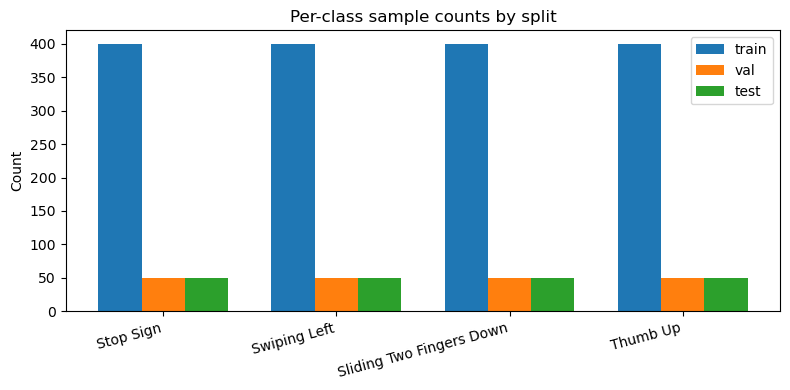

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import OrderedDict

TARGET_CLASSES = [
    "Stop Sign",
    "Swiping Left",
    "Sliding Two Fingers Down",
    "Thumb Up"
]

def counts_for(df):
    return df['gesture'].value_counts().reindex(TARGET_CLASSES).fillna(0).astype(int).values

train_counts = counts_for(df_train)
val_counts = counts_for(df_val)
test_counts = counts_for(df_test)

x = np.arange(len(TARGET_CLASSES))
width = 0.25

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x - width, train_counts, width, label='train')
ax.bar(x, val_counts, width, label='val')
ax.bar(x + width, test_counts, width, label='test')

ax.set_xticks(x)
ax.set_xticklabels(TARGET_CLASSES, rotation=15, ha='right')
ax.set_ylabel('Count')
ax.set_title('Per-class sample counts by split')
ax.legend()
plt.tight_layout()
plt.show()

## Extracting subset from the 2k subsample for quick testing of model pipelines (creating dev set)

* Makes a dev set of data for quick testing of ETL and ML pippelines 

* Save out: 
    * **/dev/raw_data/annotations/train.csv:**
        * a .csv file containning 8 video id and labels (2 videos for each gesture class) randomly selected from the 2k subsample 
    * **/dev/raw_data/annotations/val.csv:**
        * a csv file containing 4 video id and labels (i.e., 1 video with its label from each of the 4 gesture classes) randomly sampled from the 2k subsample for validation 
    * **/dev/raw_data/annotations/test.csv:** 
        * .csv file containing 4 video id and labels (i.e., 1 video with its label from each of the 4 gesture classes) randomly sampled from the 2k subsample for testing 
    *  **/dev/raw_data/videos:**
        * folder containing the train, test, val videos for development testing

In [18]:
import os
import pandas as pd
import random
import shutil

# =======================================
# Config
# =======================================

# Dev set folders 
SUBSAMPLE_VIDEOS_DIR = "../data/prod/raw_data/videos"   
DEV_DIR = "../data/dev/raw_data"    # Dir to save dev set (annotations + videos ) from existing full subsample
os.makedirs(DEV_DIR, exist_ok=True)
DEV_VIDEOS_DIR = "../data/dev/raw_data/videos"         # dir where dev subset videos will be saved 
os.makedirs(DEV_VIDEOS_DIR, exist_ok=True)
DEV_ANNOTATIONS_DIR = "../data/dev/raw_data/annotations"    # # dir where dev subset annotations will be saved 
os.makedirs(DEV_ANNOTATIONS_DIR, exist_ok=True)

# Locations of the 2k subsample video id and labels 
TRAIN_CSV = os.path.join(SUBSAMPLE_DIR, "annotations/train.csv")
VAL_CSV = os.path.join(SUBSAMPLE_DIR, "annotations/val.csv")
TEST_CSV = os.path.join(SUBSAMPLE_DIR, "annotations/test.csv")

TARGET_CLASSES = [
    "Stop Sign",
    "Swiping Left",
    "Sliding Two Fingers Down",
    "Thumb Up"
]

# Randomly sample from the 2k full subsample 
rng = random.Random(RANDOM_SEED)

# Read CSVs from full 2k subsample 
for p in (TRAIN_CSV, VAL_CSV, TEST_CSV):
    if not os.path.exists(p):
        raise FileNotFoundError(f"Expected CSV not found: {p}")
df_train = pd.read_csv(TRAIN_CSV)
df_val = pd.read_csv(VAL_CSV)
df_test = pd.read_csv(TEST_CSV)

# Helper: deterministic sample n per class using single 
def sample_per_class(df, classes, n, rng):
    out = []
    for cls in classes:
        ids = df[df['gesture'] == cls]['video_id'].astype(str).tolist()
        if len(ids) < n:
            raise ValueError(f"Not enough examples in class {cls} to sample {n} items (found {len(ids)})")
        ids_copy = ids.copy()
        rng.shuffle(ids_copy)
        chosen = ids_copy[:n]
        out.extend([(vid, cls) for vid in chosen])
    return out

# Select dev splits: 2 train per class, 1 val per class, 1 test per class
dev_train_sel = sample_per_class(df_train, TARGET_CLASSES, 2, rng)
dev_val_sel   = sample_per_class(df_val,   TARGET_CLASSES, 1, rng)
dev_test_sel  = sample_per_class(df_test,  TARGET_CLASSES, 1, rng)

# Prepare dev directories and CSV rows
splits = {
    'train': dev_train_sel,
    'val': dev_val_sel,
    'test': dev_test_sel
}
csv_rows = {'train': [], 'val': [], 'test': []}

# Helper function to resolve path of source folder
def resolve_source_folder(vid):
    vid = str(vid)  # ensure consistency
    # Look in CSVs first
    for df in (df_train, df_val, df_test):
        r = df[df['video_id'] == vid]
        if not r.empty:
            fp = r.iloc[0].get('filepath', None)
            if pd.notna(fp):
                candidate = fp if os.path.isabs(fp) else os.path.join(SUBSAMPLE_DIR, fp)
                if os.path.exists(candidate):
                    return os.path.normpath(candidate)

    # Fallback: check standard layout
    for candidate_split in ('train', 'val', 'test'):
        candidate = os.path.join(SUBSAMPLE_VIDEOS_DIR, candidate_split, vid)
        if os.path.exists(candidate):
            return os.path.normpath(candidate)

    return None
# Copy selected folders to DEV_DIR
for split_name, rows in splits.items():
    out_split_dir = os.path.join(DEV_VIDEOS_DIR, split_name)
    os.makedirs(out_split_dir, exist_ok=True)
    for vid, cls in rows:
        #  Find source folder (look up filepath in CSVs, else check standard split folders
        # source folder: use filepath in original CSV if present, else SUBSAMPLE_DIR/{split}/{video_id}
        # Try to find source path in any of the three CSVs
        src_path = resolve_source_folder(vid)
        if src_path is None:
            raise FileNotFoundError(f"Source folder for video {vid} not found under {SUBSAMPLE_VIDEOS_DIR}")
        dest_dir = os.path.join(out_split_dir, vid)
        if os.path.exists(dest_dir):
            shutil.rmtree(dest_dir)
        shutil.copytree(src_path, dest_dir)
        
        # Save relative filepath in CSV (relative to DEV_DIR)
        rel_fp = os.path.join("videos", split_name, vid)
        csv_rows[split_name].append((vid, cls, rel_fp))

# Write dev CSVs
for split_name, rows in csv_rows.items():
    df_out = pd.DataFrame(rows, columns=['video_id','gesture','filepath'])
    out_path = os.path.join(DEV_ANNOTATIONS_DIR, f"{split_name}.csv")
    df_out.to_csv(out_path, index=False)
    print(f"Wrote {out_path} ({len(df_out)} rows)")
print("Dev subset created under:", DEV_DIR)

Wrote ../data/dev/raw_data/annotations/train.csv (8 rows)
Wrote ../data/dev/raw_data/annotations/val.csv (4 rows)
Wrote ../data/dev/raw_data/annotations/test.csv (4 rows)
Dev subset created under: ../data/dev/raw_data


### Load the dev subset and verify per-class counts 

In [21]:
import os
import pandas as pd

DEV_ANNOTATIONS_DIR = "../data/dev/raw_data/annotations"   
DEV_TRAIN_CSV = os.path.join(DEV_ANNOTATIONS_DIR, "train.csv")
DEV_VAL_CSV = os.path.join(DEV_ANNOTATIONS_DIR, "val.csv")
DEV_TEST_CSV = os.path.join(DEV_ANNOTATIONS_DIR, "test.csv")

TARGET_CLASSES = [
    "Stop Sign",
    "Swiping Left",
    "Sliding Two Fingers Down",
    "Thumb Up"
]

# ==============================================
# Verify counts per class for each train/val/test
# ===============================================
def check_counts(csv_path, expected_per_class=None):
    df = pd.read_csv(csv_path)
    counts = df['gesture'].value_counts().reindex(TARGET_CLASSES).fillna(0).astype(int)
    print(f"\nCounts for {os.path.basename(csv_path)}:")
    print(counts.to_string())
    if expected_per_class is not None:
        mismatches = {c: int(counts[c]) for c in TARGET_CLASSES if counts[c] != expected_per_class}
        if mismatches:
            print(f"Mismatch vs expected {expected_per_class} per class: {mismatches}")
        else:
            print(f"All classes have the expected {expected_per_class} samples.")
    return df

# Verify counts and load DataFrames
df_dev_train = check_counts(DEV_TRAIN_CSV, expected_per_class=2)
df_dev_val = check_counts(DEV_VAL_CSV, expected_per_class=1)
df_dev_test = check_counts(DEV_TEST_CSV, expected_per_class=1)


Counts for train.csv:
gesture
Stop Sign                   2
Swiping Left                2
Sliding Two Fingers Down    2
Thumb Up                    2
All classes have the expected 2 samples.

Counts for val.csv:
gesture
Stop Sign                   1
Swiping Left                1
Sliding Two Fingers Down    1
Thumb Up                    1
All classes have the expected 1 samples.

Counts for test.csv:
gesture
Stop Sign                   1
Swiping Left                1
Sliding Two Fingers Down    1
Thumb Up                    1
All classes have the expected 1 samples.
